# Set-up

In [104]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

In [105]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [106]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [107]:
path_out = "scratch/2025_04_29"

In [108]:
dtype = torch.float64

seq_len = 2114
target_len = 1000
mut_window = 500
plot_window = 300

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - mut_window // 2
seq_end = seq_center + mut_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - mut_window // 2
target_end = target_center + mut_window // 2

# Plot starts
plot_seq_center = 1050
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

seq_start: 807, seq_end: 1307
target_start: 250, target_end: 750
plot_seq_start: 907, plot_seq_end: 1207
plot_target_start: 350, plot_target_end: 650


# Load genome

In [109]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [110]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load motifs

In [111]:
motifs = read_meme("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")
motif_names = np.array(list(motifs.keys()))

In [112]:
tmp = pd.read_csv("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/tfs_initial.txt", header=None, sep='\t', names=["motif_id", "annotated_tf"])
motif_id_mp = tmp.set_index("motif_id")["annotated_tf"]

# Load model

In [113]:
path_model = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/SC.beta/fold_0/chrombpnet/0.8/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

In [114]:
count_wrapper = CountWrapper(model).cuda().eval()

# Original sequence

In [115]:
# chr5:51392146-51392917
chrom = "chr5"
start = 51392146
end = 51392917

In [116]:
original_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATATTTACCTGGAGGGCATTTGCTTTCTCAATGTCAACAGTTAGGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTGCAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()
len(original_seq)

772

In [117]:
# Get the sequence corresponding to the region of interest from the genome fasta
seq = genome[chrom][start-1:end].seq.upper()
seq

'AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATATTTACCTGGAGGGCATTTGCTTTCTCAATGTCAACAGTTAGGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTGCAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC'

In [118]:
seq == original_seq

True

In [119]:
# get flanking sequence from reference that would make the sequence length equal to seq_len
flank_len = (seq_len - len(original_seq)) // 2
flank_len

671

In [120]:
# Concatenate the left flank, original sequence, and right flank to create the full sequence
left_flank = genome[chrom][start-flank_len-1:start-1].seq.upper()
right_flank = genome[chrom][end:end+flank_len].seq.upper()
full_seq = (left_flank + original_seq + right_flank).upper()
len(full_seq)

2114

In [121]:
# Get predictions
original_seq_onehot = np.expand_dims(sp.ohe(full_seq, alphabet=sp.DNA), 0).transpose(0, 2, 1)
original_profile, original_counts = predict(model, torch.tensor(original_seq_onehot).float().cuda())
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")

original counts: 979.5540161132812


In [122]:
# Get attribution scores for the original sequence
X_attr = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(original_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=8,
    verbose=True,
    warning_threshold=1e-4
)
X_attr.shape

100%|██████████| 20/20 [00:00<00:00, 25.03it/s]


torch.Size([1, 4, 2114])

In [123]:
seqlets = recursive_seqlets(X_attr[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(original_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [124]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,ETV6_MOUSE.H11MO.0.C,910,925,-0.067647,1.110223e-15
1,FOXA2_HUMAN.H11MO.0.A,1043,1060,0.300481,2.881844e-03
2,NFYB_HUMAN.H11MO.0.A,997,1012,0.225012,2.318841e-02
3,FOXA2_HUMAN.H11MO.0.A,984,998,0.174367,3.003003e-02
4,IRF2_HUMAN.H11MO.0.A,1251,1265,-0.053087,3.333333e-02


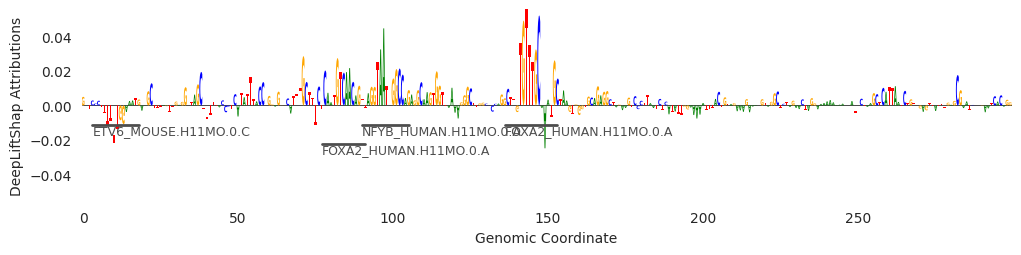

In [125]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

# Mutated sequences

In [126]:
mutated_preds = []

## Mutated Sequence #1

In [127]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [128]:
mutated_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATTTGTACCTGGAGGGCATTTGTTTACTCAATGTAAACAGTTAGGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTACAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()

In [129]:
# Find all the differences between the original and mutated sequences, both the change and the position
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(288, 'A', 'T'),
 (290, 'T', 'G'),
 (308, 'C', 'T'),
 (311, 'T', 'A'),
 (320, 'C', 'A'),
 (382, 'G', 'A')]

In [130]:
# add left flank and right flank to mutated sequence
mutated_seq_full = (left_flank + mutated_seq + right_flank).upper()
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq_full, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
print(f"mutated counts: {mutated_counts}")

mutated counts: 1750.7467041015625


In [131]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=4,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 24.54it/s]


torch.Size([1, 4, 2114])

In [132]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [133]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,ETV6_MOUSE.H11MO.0.C,910,925,-0.082737,1.110223e-15
1,FOXA2_HUMAN.H11MO.0.A,1044,1059,0.361290,2.967359e-03
2,FOXA2_HUMAN.H11MO.0.A,973,989,0.396531,1.186944e-02
3,FOXA2_HUMAN.H11MO.0.A,984,998,0.316511,2.985075e-02
4,IRF2_HUMAN.H11MO.0.A,1251,1265,-0.049412,3.164557e-02


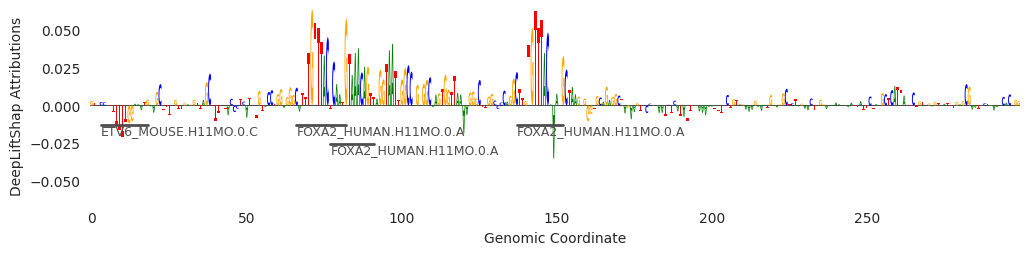

In [134]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

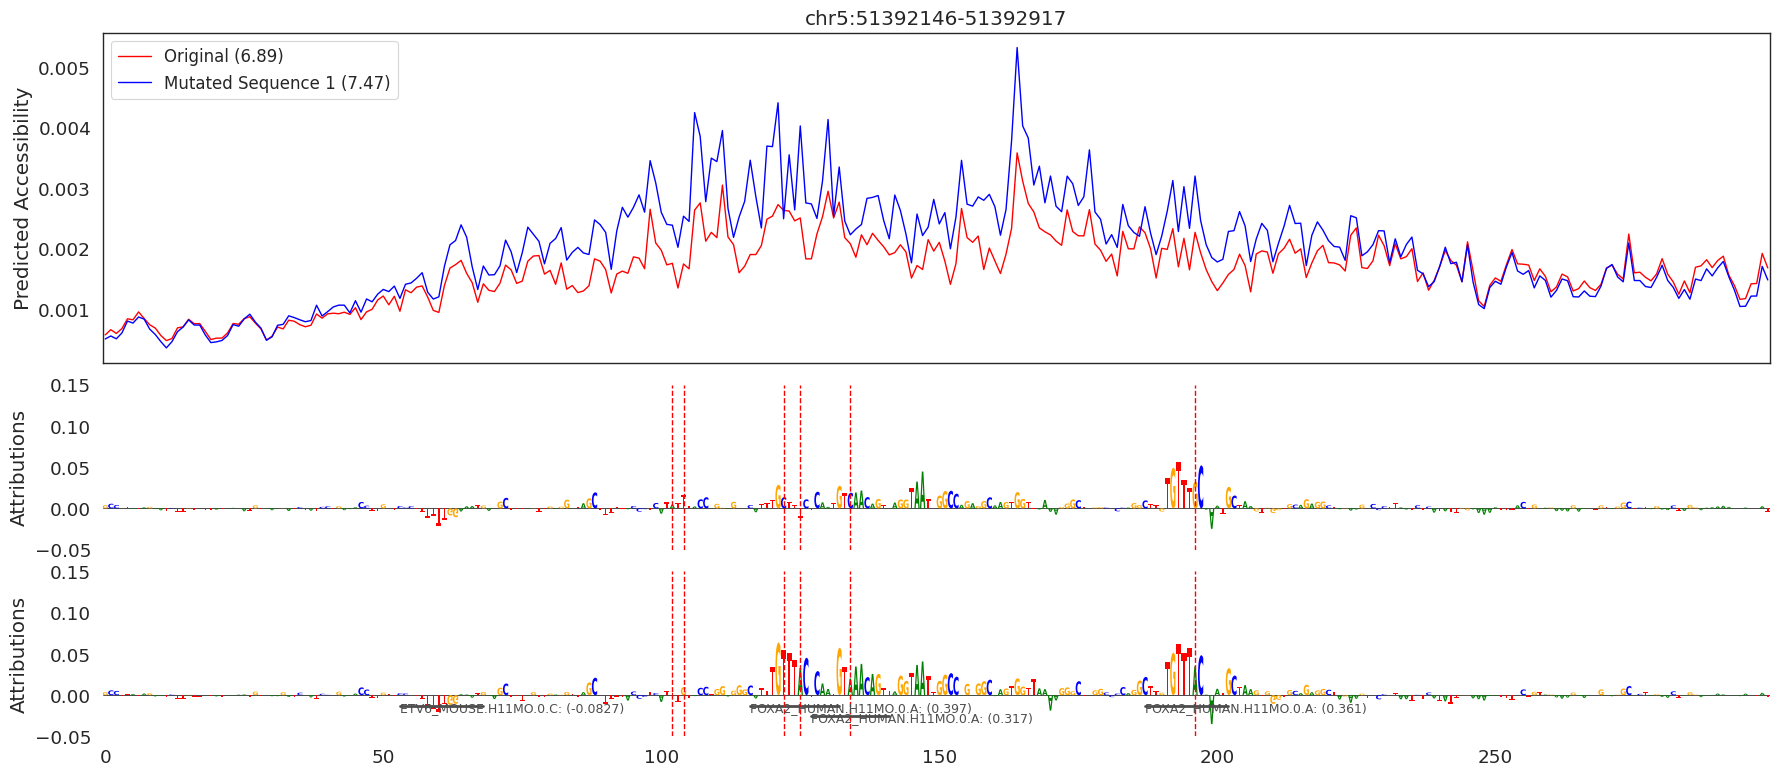

In [135]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_profile[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_profile[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence 1 ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos + len(left_flank) - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_1_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [136]:
mutated_preds.append(np.log(mutated_counts))

## Mutated Sequence #2

In [137]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [138]:
mutated_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATGTTTACCTGGAGGGCATTTGTTTACTCAATGTAAACAGTTAGGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTACAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()

In [139]:
# Find all the differences between the original and mutated sequences, both the change and the position
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(288, 'A', 'G'),
 (308, 'C', 'T'),
 (311, 'T', 'A'),
 (320, 'C', 'A'),
 (382, 'G', 'A')]

In [140]:
# add left flank and right flank to mutated sequence
mutated_seq_full = (left_flank + mutated_seq + right_flank).upper()
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq_full, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
print(f"mutated counts: {mutated_counts}")

mutated counts: 3059.09423828125


In [141]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=4,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 24.33it/s]


torch.Size([1, 4, 2114])

In [142]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [143]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,1043,1058,0.389840,0.003175
1,ETV6_MOUSE.H11MO.0.C,910,925,-0.087157,0.011111
2,FOXA2_HUMAN.H11MO.0.A,973,990,0.565233,0.012539
3,FOXA2_HUMAN.H11MO.0.A,986,1000,0.412435,0.022222


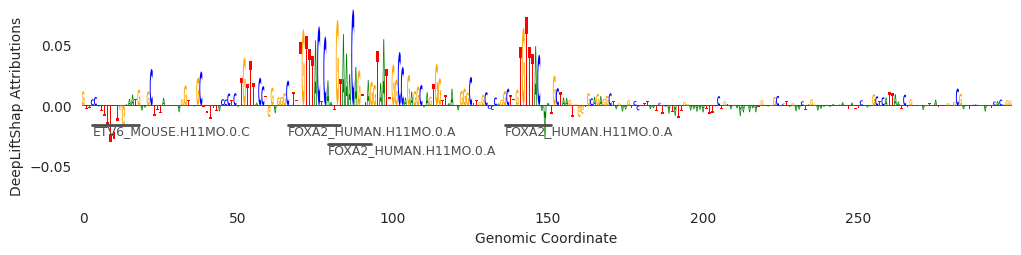

In [144]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

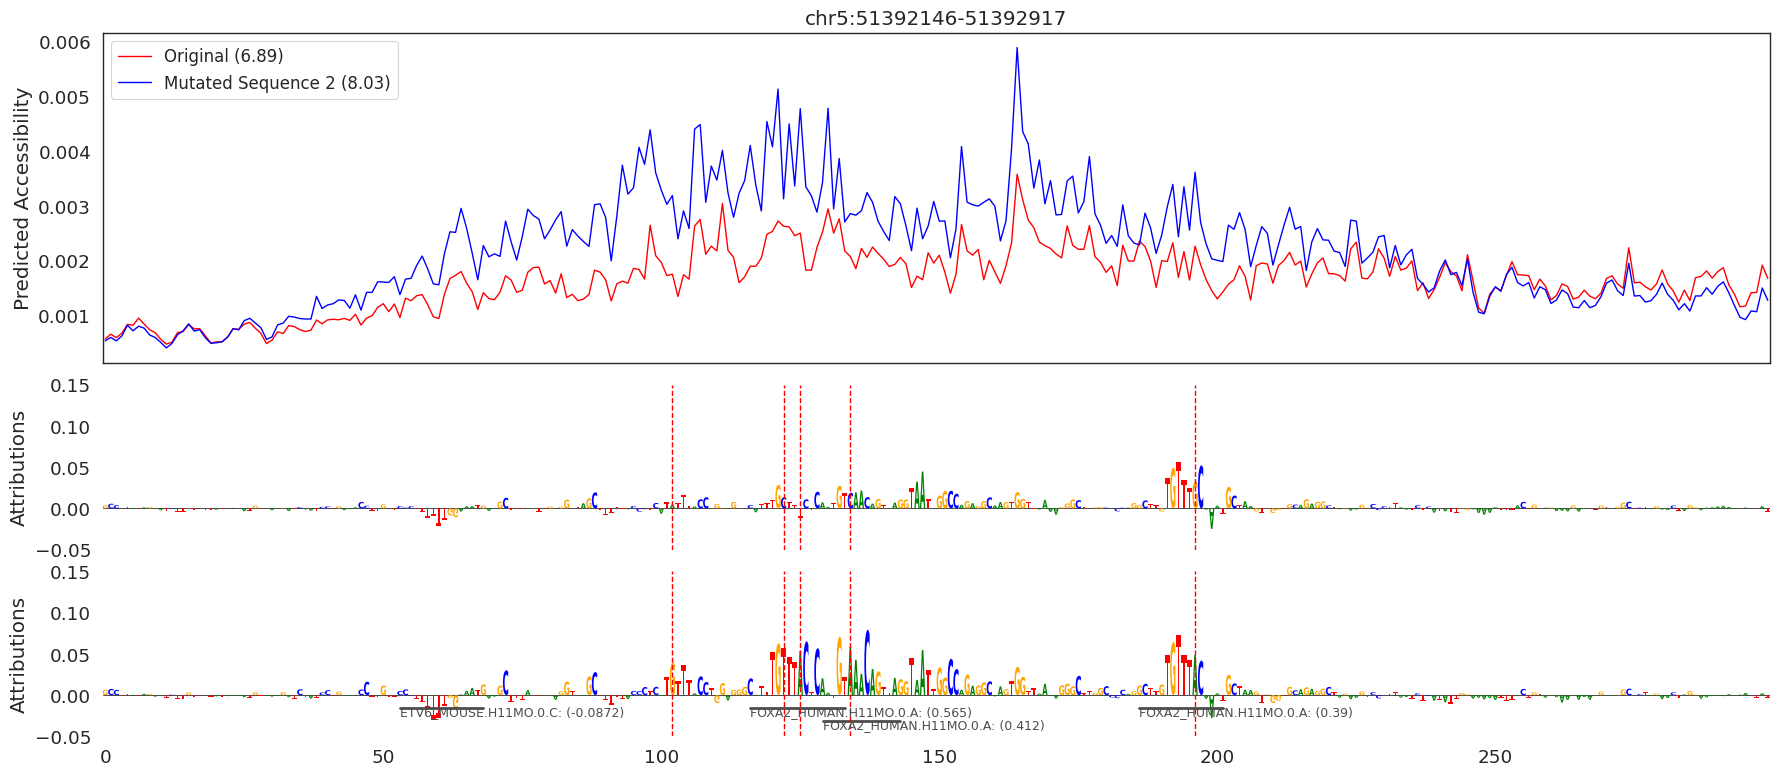

In [145]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_profile[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_profile[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence 2 ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos + len(left_flank) - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_2_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [146]:
mutated_preds.append(np.log(mutated_counts))

## Mutated Sequence #3

In [147]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [148]:
mutated_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATTTGTTTACCTGGAGGGCATTTGTTTACTCAATGTAAACAGTTAGGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTACAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()

In [149]:
left_flank_for_3 = left_flank[1:]
right_flank_for_3 = right_flank[:-1]

In [150]:
# add left flank and right flank to mutated sequence
mutated_seq_full = (left_flank_for_3 + mutated_seq + right_flank_for_3).upper()
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq_full, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
print(f"mutated counts: {mutated_counts}")

mutated counts: 3579.0400390625


In [151]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=4,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 24.11it/s]


torch.Size([1, 4, 2114])

In [152]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [153]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,973,991,0.710284,0.003067
1,ETV6_MOUSE.H11MO.0.C,908,924,-0.081255,0.005714
2,FOXA2_HUMAN.H11MO.0.A,1044,1058,0.340113,0.015198
3,IRF2_HUMAN.H11MO.0.A,1252,1266,-0.050515,0.034286
4,FOXA2_HUMAN.H11MO.0.A,987,1001,0.428404,0.039514


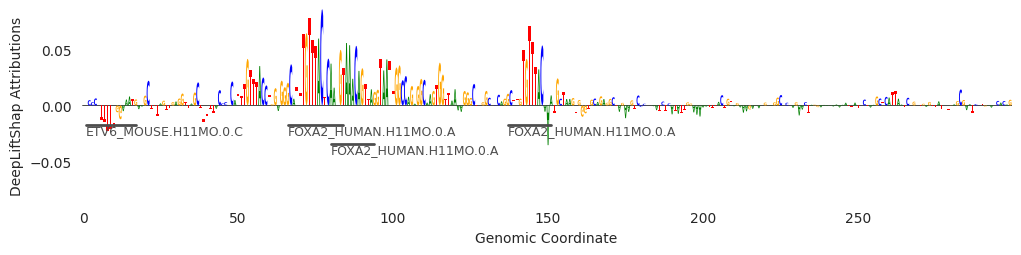

In [154]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

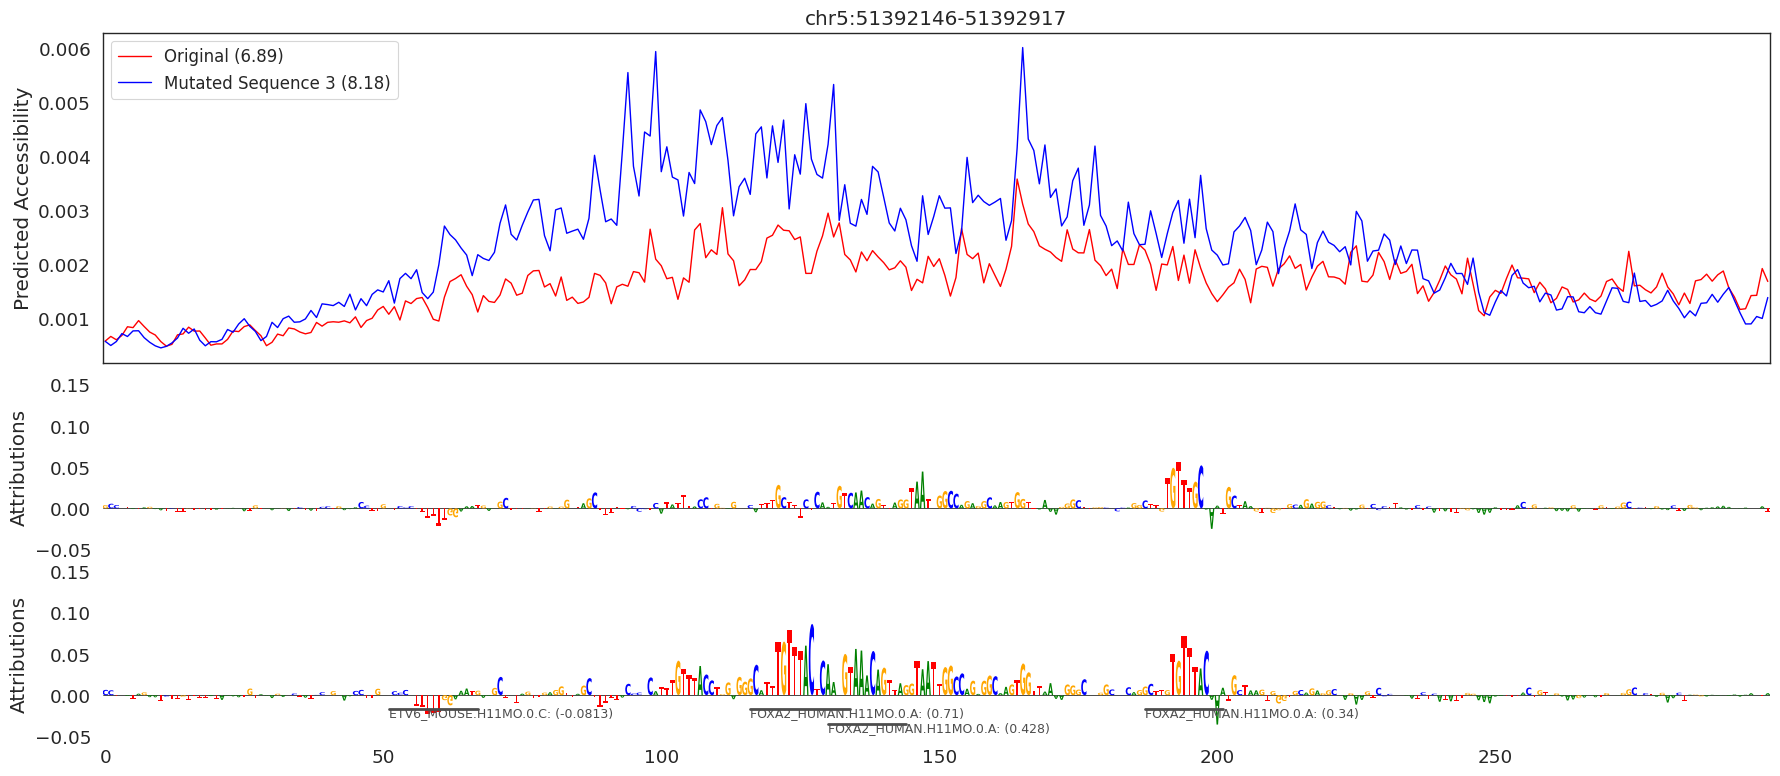

In [155]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_profile[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_profile[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence 3 ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)


    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_3_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [156]:
mutated_preds.append(np.log(mutated_counts))

## Mutated Sequence #4

In [157]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [158]:
mutated_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATTTGTACCTGGAGGGCATTTGTTTACTCATTTGTAAACATTTGTGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTACAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()

In [159]:
left_flank_for_4 = left_flank[1:]

In [160]:
# add left flank and right flank to mutated sequence
mutated_seq_full = (left_flank_for_4 + mutated_seq + right_flank).upper()
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq_full, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
print(f"mutated counts: {mutated_counts}")

mutated counts: 1762.33056640625


In [161]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=8,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 24.30it/s]


torch.Size([1, 4, 2114])

In [162]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [163]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,1044,1059,0.344993,0.003226
1,IRF2_HUMAN.H11MO.0.A,1251,1266,-0.060291,0.005587
2,FOXA2_HUMAN.H11MO.0.A,997,1011,0.410078,0.012987
3,ETV6_MOUSE.H11MO.0.C,909,924,-0.046516,0.016760


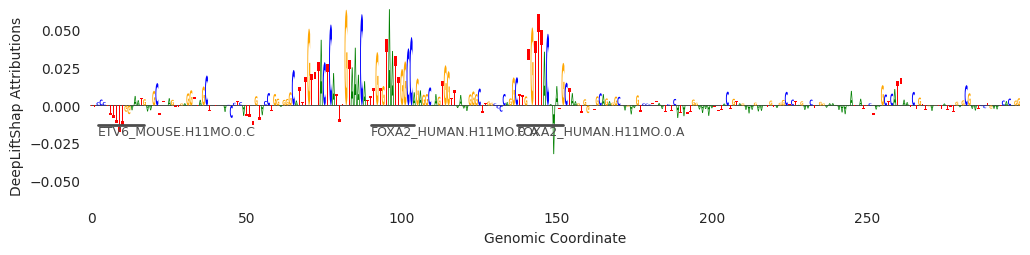

In [164]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

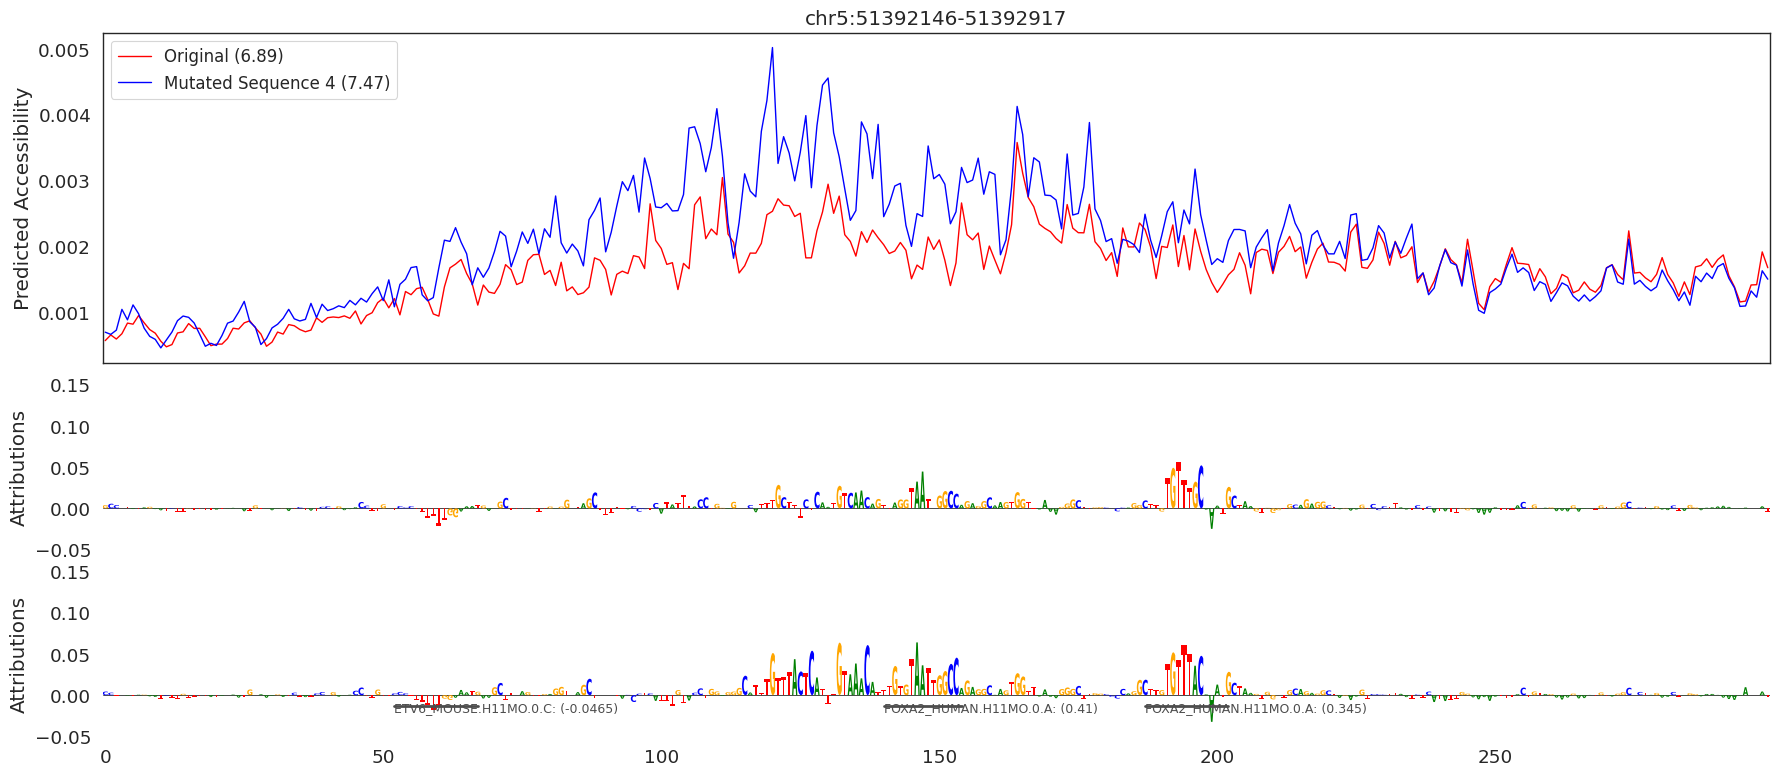

In [165]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_profile[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_profile[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence 4 ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)


    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_4_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [166]:
mutated_preds.append(np.log(mutated_counts))

## Mutated Sequence #5

In [167]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [168]:
mutated_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATGTTTACCTGGAGGGCATTTGTTTACTCATTTGTAAACATTTGTGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTACAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()

In [169]:
left_flank_for_5 = left_flank[1:]

In [170]:
# add left flank and right flank to mutated sequence
mutated_seq_full = (left_flank_for_4 + mutated_seq + right_flank).upper()
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq_full, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
print(f"mutated counts: {mutated_counts}")

mutated counts: 3112.176025390625


In [171]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=8,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 24.51it/s]


torch.Size([1, 4, 2114])

In [172]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [173]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,1044,1058,0.337858,0.003356
1,ETV6_MOUSE.H11MO.0.C,908,925,-0.080312,0.011696
2,FOXA2_HUMAN.H11MO.0.A,997,1011,0.494790,0.016234
3,FOXA2_HUMAN.H11MO.0.A,972,988,0.418341,0.020134


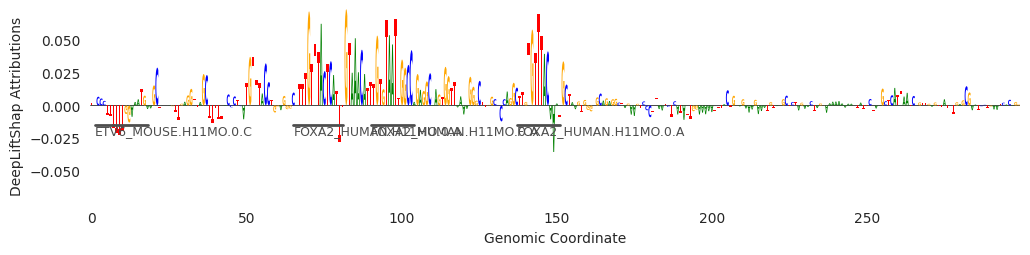

In [174]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

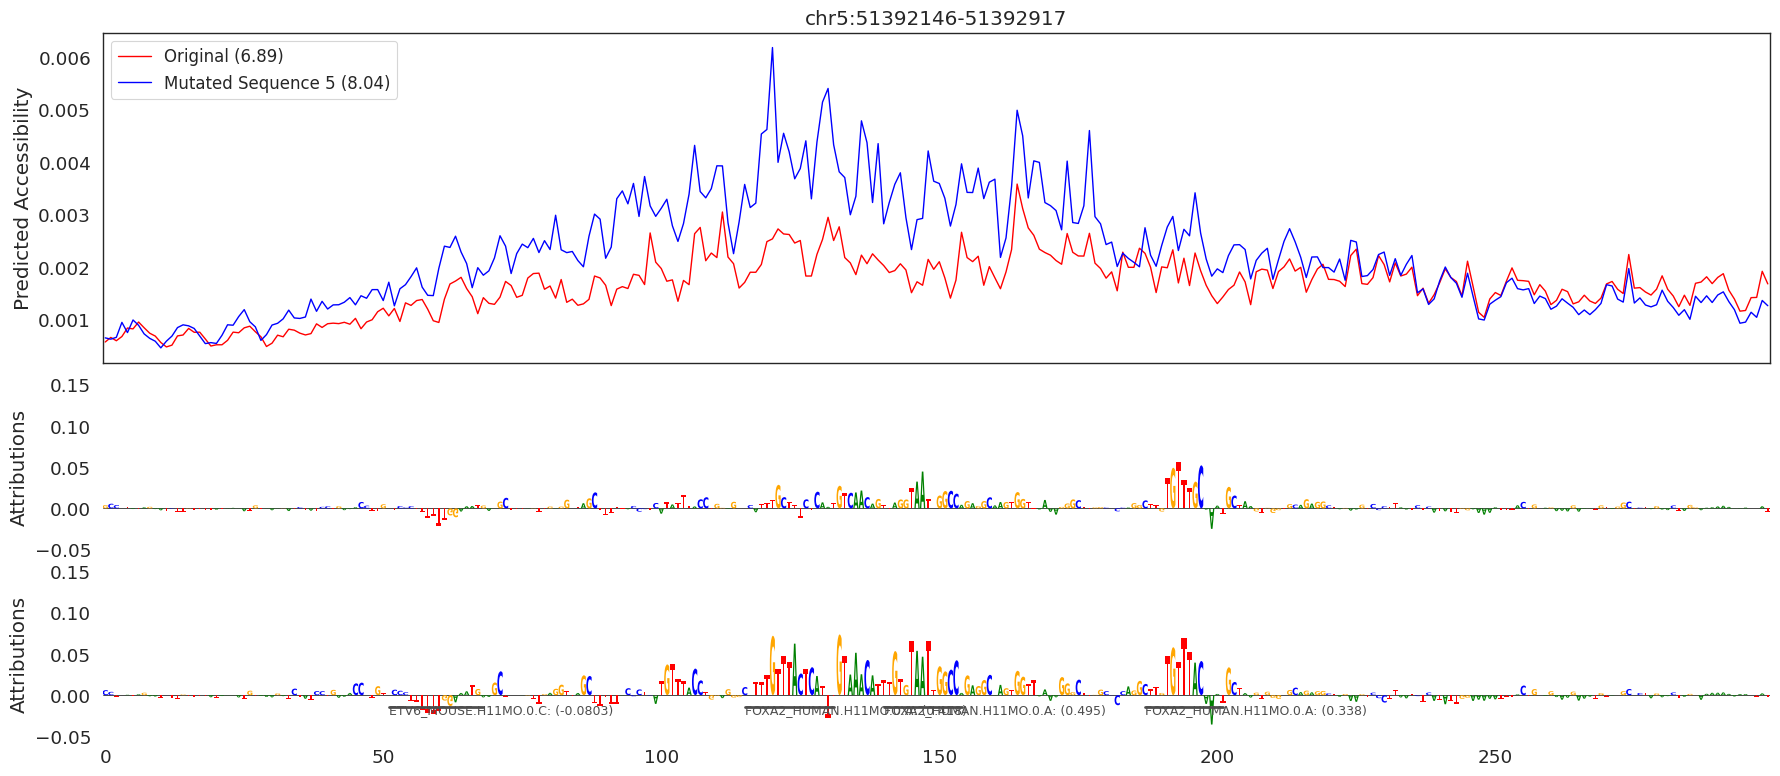

In [175]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_profile[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_profile[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence 5 ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)


    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_5_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [176]:
mutated_preds.append(np.log(mutated_counts))

## Mutated Sequence #6

In [177]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [178]:
mutated_seq = "AATCAGAAGTAAAGTGTTTAATCTGTGAAAACCTTAACATGTTTTCCACATCCAGAGAGGAGAAAATTAATTCACTTTTTGCCTACAAAAGGCTTAAGGGGTCAAGATAAATAAGAACAATAAATATATGTCCTTTGTAATATGCTATATTTATATAGATGATTTTTTTTTCTTAAAGAGTAATCAGCCTTATAGAATCTTGTTTTATAAAATGTAAAGATCTATCCTGAAACCTTGTTCCCTTTTTTGGAAATGAAGCTTTAGTTGAGGTTAGCTTTTTACCCTCATTTGTACCTGGAGGGCATTTGTTTACTCATTTGTAAACATTTGTGTAATTGGCCAGAGGCAAGTGGTTAAAAGGGCTTGGCCCCAGGCTTGTGTTTACAAATGCTAAGTGGGTGCAGAGGCTAGAAGTCCCTTAATCTCATATTGGAAAAATTTACTGTAGAAAGAAATGTAGGCTCTAGAACTAGGAAAAAAAAATTATTCTAAGCTCATTAATCTGTTGAGTTATTTGAGCGAATCCTGAATCACAGGAGGAAGGTAAGGGGAGGCTTCAGGGCAGCCAAATGTTTGCACTTTCTGAAACTTTAGTGTCAGATGAGAGCAGTGGAAGGGAAGCTGAGGCAGGAGTGGGCATAGTTAGAGAAGGTTTACAACAGCAGTACAATGCGTTTAGGGTTAAAAGAAGGAGTCAGATATTTAAGAAGGAGTCAGATATTAGGGTTAAAAGAAGGAGTCAGAATGGGATGATGTCATAATATATGGGTCTC".upper()

In [179]:
left_flank_for_6 = left_flank[2:]
right_flank_for_6 = right_flank[:-1]

In [180]:
# add left flank and right flank to mutated sequence
mutated_seq_full = (left_flank_for_6 + mutated_seq + right_flank_for_6).upper()
mutated_seq_onehot = np.expand_dims(sp.ohe(mutated_seq_full, alphabet=sp.DNA), 0).transpose(0, 2, 1)
mutated_profile, mutated_counts = predict(model, torch.tensor(mutated_seq_onehot).float().cuda())
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())
print(f"mutated counts: {mutated_counts}")

mutated counts: 1770.644287109375


In [181]:
# Get attribution scores for the original sequence
X_attr_mutated = deep_lift_shap(
    count_wrapper.type(dtype), 
    torch.tensor(mutated_seq_onehot).type(dtype).cuda(),
    n_shuffles=20,
    batch_size=8,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_mutated.shape

100%|██████████| 20/20 [00:00<00:00, 24.84it/s]


torch.Size([1, 4, 2112])

In [182]:
seqlets = recursive_seqlets(X_attr_mutated[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(torch.tensor(mutated_seq_onehot)[:, :, seq_start:seq_end], seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
seqlets['start'] += seq_start
seqlets['end'] += seq_start

In [183]:
seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,1042,1058,0.368929,1.776357e-15
1,ETV6_MOUSE.H11MO.0.C,908,923,-0.075478,5.681818e-03
2,FOXA2_HUMAN.H11MO.0.A,996,1011,0.434550,1.567398e-02
3,IRF2_HUMAN.H11MO.0.A,1250,1264,-0.061287,3.932584e-02


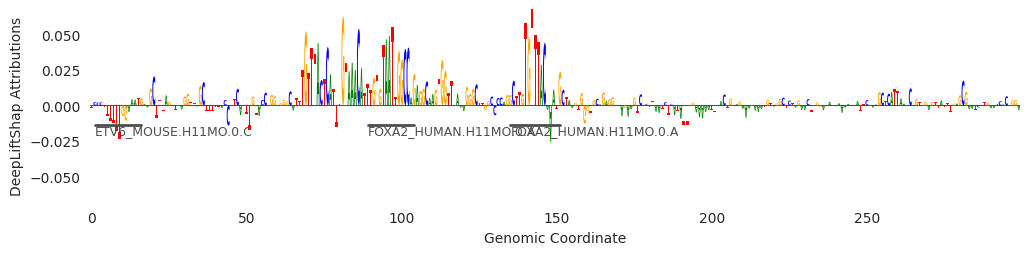

In [184]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_attr_mutated[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=seqlets, score_key='attribution', n_tracks=2, show_extra=False, show_score=False)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

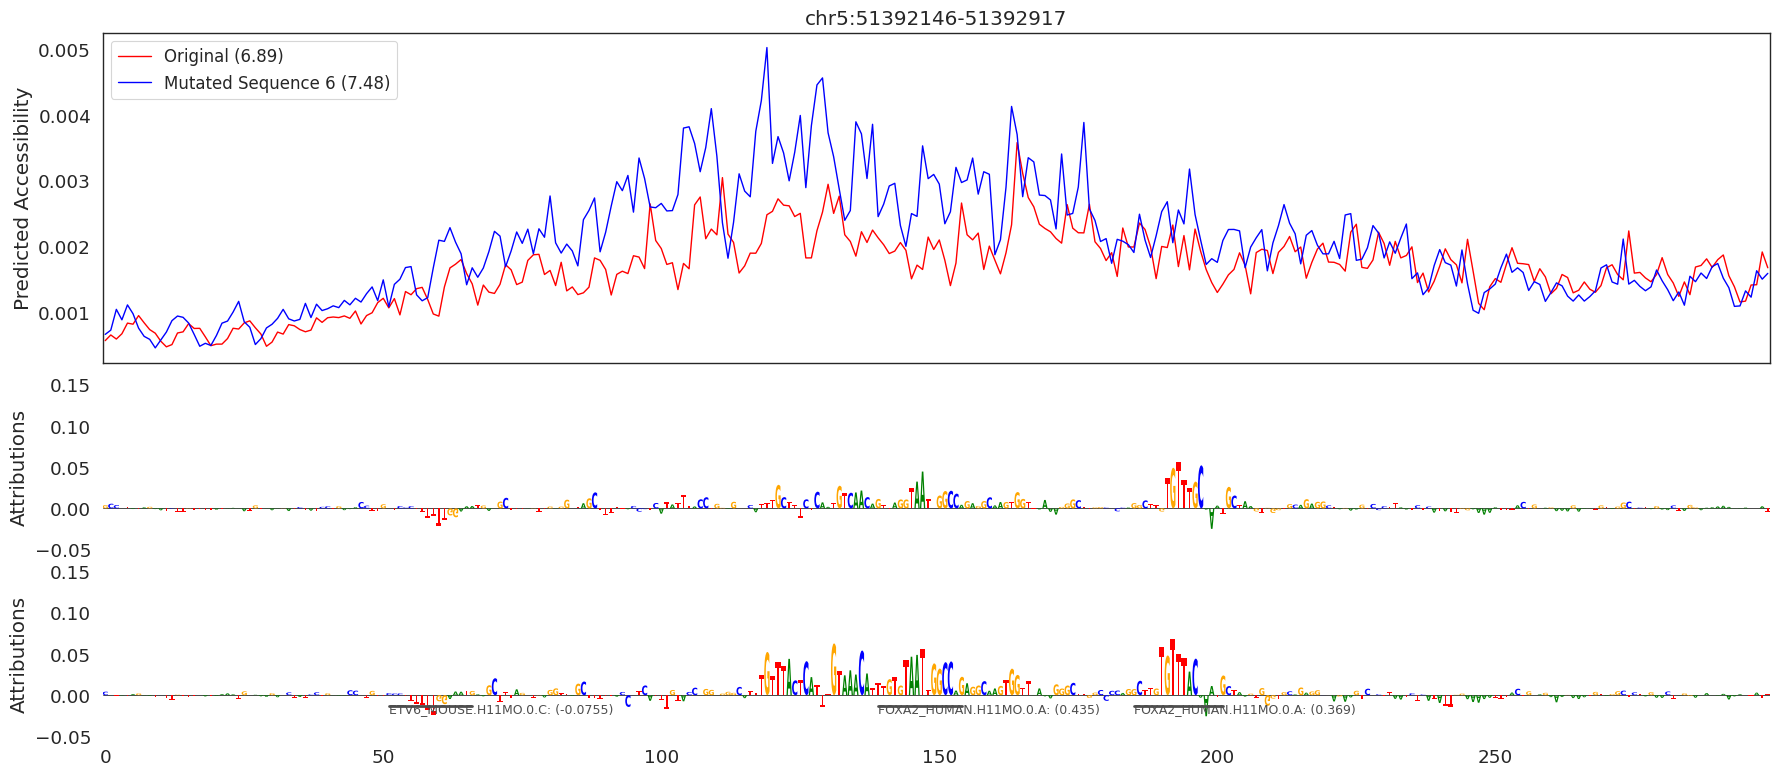

In [185]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_profile[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_profile[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated Sequence 6 ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom}:{start}-{end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr[0, :, plot_seq_start+offset:plot_seq_end+offset], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_attr_mutated[0], ax=axes[2], start=plot_seq_start+offset, end=plot_seq_end+offset, annotations=seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)


    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_manual_6_{chrom}_{start}-{end}.pdf"), bbox_inches='tight', dpi=300)

In [186]:
mutated_preds.append(np.log(mutated_counts))

# Histogram

In [187]:
peaks_selected = pd.read_csv("ISL1_enhancer_predictions.csv")

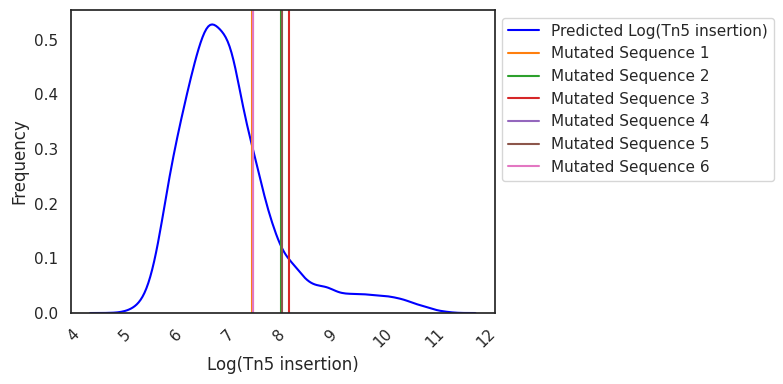

Exception ignored in atexit callback: <bound method InteractiveShell.atexit_operations of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x15555114c590>>
Traceback (most recent call last):
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3952, in atexit_operations
    self._atexit_once()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3935, in _atexit_once
    self.history_manager.end_session()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/history.py", line 592, in end_session
    self.writeout_cache()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/decorator.py", line 232, in fun
    return caller(func, *(extras + args), **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cellar/users/aklie/opt/miniconda3/envs/eug

In [ ]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.kdeplot(
        peaks_selected["log_counts_pred"],
        color='blue',
        label='Predicted Log(Tn5 insertion)',
        ax=ax
    )

    # Plot each ISL1 enhancer as a vertical line each with a different color
    for i, pred in enumerate(mutated_preds):
        ax.axvline(
            [pred],
            color=f'C{i+1}',
            label=f'Mutated Sequence {i+1}',
        )

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()
    plt.savefig(os.path.join(path_out, "ISL1_manual_enhancer_predictions_histogram.pdf"), bbox_inches='tight', dpi=300)

# DONE!

---